In [36]:
import pickle
import librosa
import numpy as np
import librosa.display
from pathlib import Path
import IPython.display as ipd
import matplotlib.pyplot as plt

In [21]:
NEY_DIR = "dataset/ney/"
GTR_DIR = "dataset/ac_gtr/"

In [22]:
ney_files = sorted([NEY_DIR + f.name for f in Path(NEY_DIR).rglob("*.wav")])
gtr_files = sorted([GTR_DIR + f.name for f in Path(GTR_DIR).rglob("*.wav")])

In [23]:
print(ney_files[0])
print(gtr_files[0])

dataset/ney/00_Ney_C_3.wav
dataset/ac_gtr/00_Gtr_C_3.wav


In [24]:
SR = 48000
MONO = True

In [25]:
ipd.Audio(ney_files[0], rate=SR)

In [26]:
signal, _ = librosa.load(ney_files[0], mono=MONO, sr=SR)
print(signal.shape)

(102000,)


In [27]:
FRAME_SIZE = 512
HOP_LENGTH = 256

In [32]:
stft = librosa.stft(signal, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH)[:-1]
print(stft.shape)

(256, 399)


In [33]:
spectrogram = np.abs(stft)
log_spectrogram = librosa.amplitude_to_db(spectrogram)

In [49]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(
        Y,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis)

    plt.colorbar()

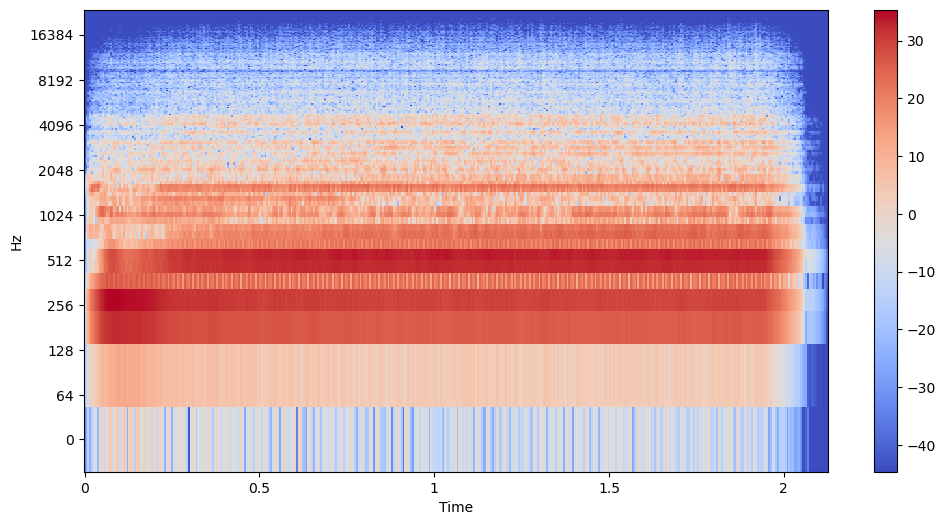

In [50]:
plot_spectrogram(log_spectrogram, SR, HOP_LENGTH, y_axis="log")

In [37]:
NEY_SPECTROGRAM_DIR = "dataset/spectrograms/ney/"
GTR_SPECTROGRAM_DIR = "dataset/spectrograms/ac_gtr/"

In [42]:
Path(ney_files[0]).stem + ".npy"

'00_Ney_C_3.npy'

In [44]:
with open(NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", "wb") as f:
    pickle.dump(log_spectrogram, f)

In [46]:
loaded_log_spectrogram = np.load(
    NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", allow_pickle=True)

In [47]:
loaded_log_spectrogram.shape

(256, 399)

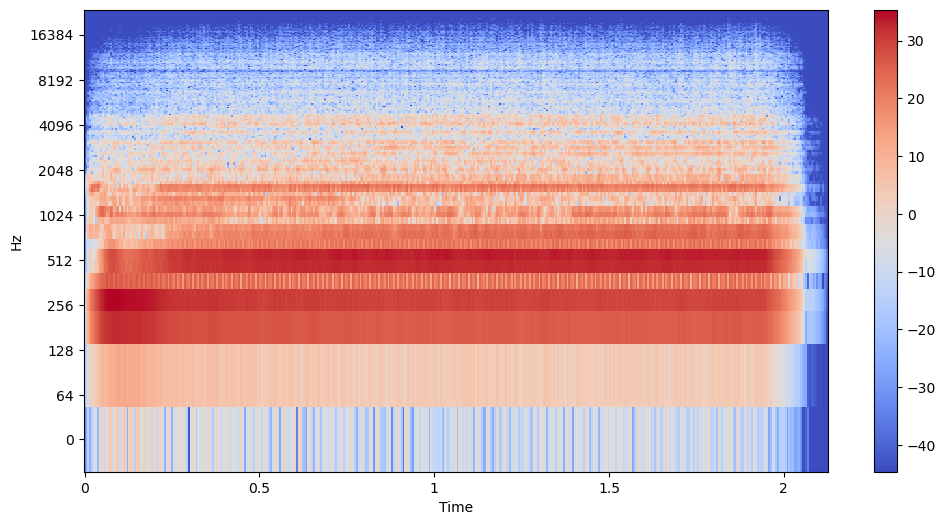

In [51]:
plot_spectrogram(loaded_log_spectrogram, SR, HOP_LENGTH, y_axis="log")

In [65]:
class SignalHandler:
    def __init__(self,
                 ney_audio_dir,
                 gtr_audio_dir,
                 ney_spectrogram_dir,
                 gtr_spectrogram_dir,
                 sr,
                 mono,
                 frame_size,
                 hop_length):
        self.ney_audio_dir = ney_audio_dir
        self.gtr_audio_dir = gtr_audio_dir
        self.ney_spectrogram_dir = ney_spectrogram_dir
        self.gtr_spectrogram_dir = gtr_spectrogram_dir
        self.sr = sr
        self.mono = mono
        self.frame_size = frame_size
        self.hop_length = hop_length
        self.ney_file_paths = []
        self.gtr_file_paths = []
        self.ney_audio_signals = []
        self.gtr_audio_signals = []
        self.ney_spectrograms = []
        self.gtr_spectrograms = []

    def load_audio_files(self):
        ney_files = sorted(
            [NEY_DIR + f.name for f in Path(NEY_DIR).rglob("*.wav")])
        self.ney_file_paths = ney_files.copy()

        gtr_files = sorted(
            [GTR_DIR + f.name for f in Path(GTR_DIR).rglob("*.wav")])
        self.gtr_file_paths = gtr_files.copy()

        for ney_file in ney_files:
            signal, _ = librosa.load(ney_file, mono=self.mono, sr=self.sr)
            self.ney_audio_signals.append(signal)

        for gtr_file in gtr_files:
            signal, _ = librosa.load(gtr_file, mono=self.mono, sr=self.sr)
            self.gtr_audio_signals.append(signal)

    def create_spectrograms(self):
        for signal in self.ney_audio_signals:
            stft = librosa.stft(signal, 
                                n_fft=self.frame_size,
                                hop_length=self.hop_length)[:-1]
            spectrogram = np.abs(stft)
            log_spectrogram = librosa.amplitude_to_db(spectrogram)
            self.ney_spectrograms.append(log_spectrogram)

        for signal in self.gtr_audio_signals:
            stft = librosa.stft(signal, 
                                n_fft=self.frame_size,
                                hop_length=self.hop_length)[:-1]
            spectrogram = np.abs(stft)
            log_spectrogram = librosa.amplitude_to_db(spectrogram)
            self.gtr_spectrograms.append(log_spectrogram)

    def save_spectrograms(self):
        for file_path, spectrogram in zip(self.ney_file_paths, self.ney_spectrograms):
            with open(self.ney_spectrogram_dir + Path(file_path).stem + ".npy", "wb") as f:
                pickle.dump(spectrogram, f)
        
        for file_path, spectrogram in zip(self.gtr_file_paths, self.gtr_spectrograms):
            with open(self.gtr_spectrogram_dir + Path(file_path).stem + ".npy", "wb") as f:
                pickle.dump(spectrogram, f)

In [62]:
NEY_DIR = "dataset/ney/"
GTR_DIR = "dataset/ac_gtr/"
NEY_SPECTROGRAM_DIR = "dataset/spectrograms/ney/"
GTR_SPECTROGRAM_DIR = "dataset/spectrograms/ac_gtr/"
SR = 48000
MONO = True
FRAME_SIZE = 512
HOP_LENGTH = 256

In [66]:
signal_handler = SignalHandler(NEY_DIR,
                               GTR_DIR,
                               NEY_SPECTROGRAM_DIR,
                               GTR_SPECTROGRAM_DIR,
                               SR,
                               MONO,
                               FRAME_SIZE,
                               HOP_LENGTH)

signal_handler.load_audio_files()
signal_handler.create_spectrograms()
signal_handler.save_spectrograms()

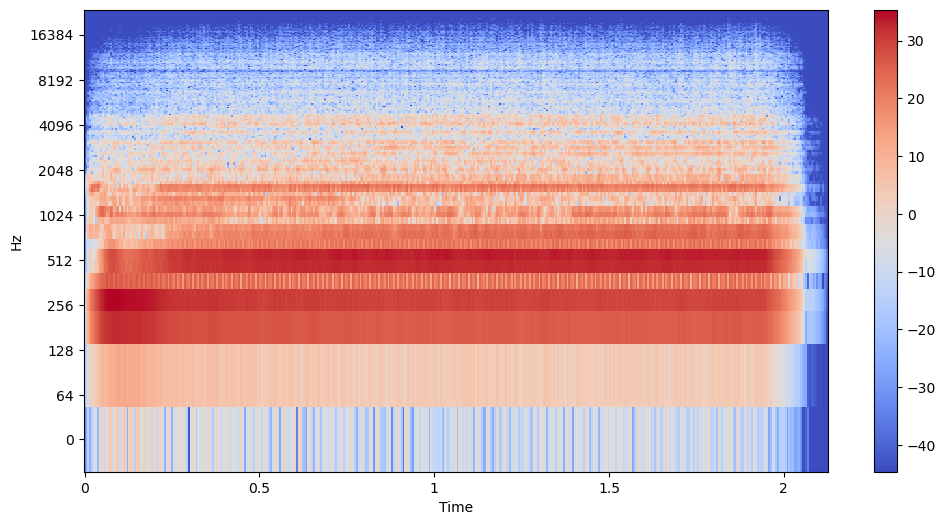

In [67]:
loaded_log_spectrogram = np.load(
    NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", allow_pickle=True)
plot_spectrogram(loaded_log_spectrogram, SR, HOP_LENGTH, y_axis="log")

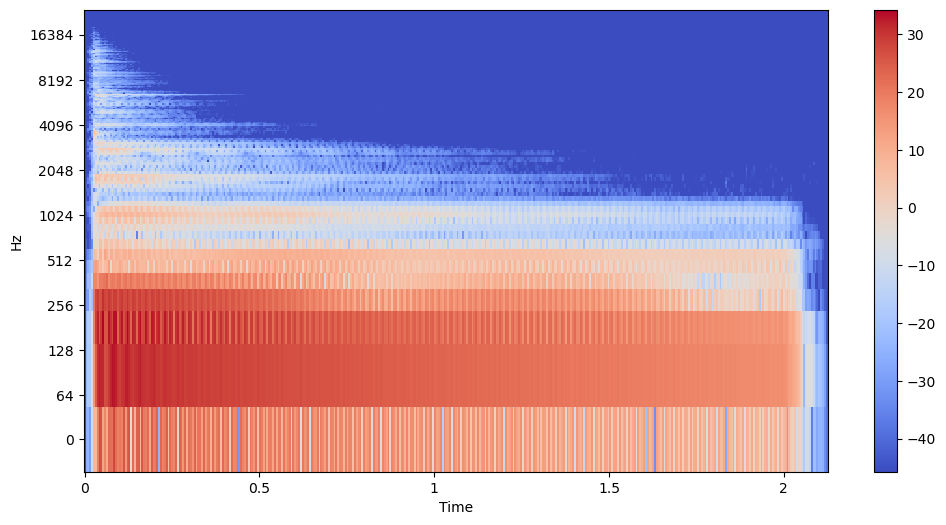

In [68]:
loaded_log_spectrogram = np.load(
    GTR_SPECTROGRAM_DIR + Path(gtr_files[0]).stem + ".npy", allow_pickle=True)
plot_spectrogram(loaded_log_spectrogram, SR, HOP_LENGTH, y_axis="log")